# HW08-09: PyTorch MLP

## 1) Импорты, seed и устройство

In [13]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torchvision

SEED = 42


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"torch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")

Device: cpu
torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


## 2) Данные и DataLoader

In [2]:
ROOT = Path(".")
ARTIFACTS_DIR = ROOT / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_DIR = ROOT / "data"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 128
VAL_RATIO = 0.2
DATASET_NAME = "EMNIST"
NUM_CLASSES = 47

transform = transforms.ToTensor()

full_train_dataset = datasets.EMNIST(
    root=str(DATA_DIR),
    split="balanced",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.EMNIST(
    root=str(DATA_DIR),
    split="balanced",
    train=False,
    download=True,
    transform=transform,
)

print(f"{DATASET_NAME} (balanced) loaded from torchvision.")

train_size = int((1 - VAL_RATIO) * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train size: {len(train_dataset)}")
print(f"Val size:   {len(val_dataset)}")
print(f"Test size:  {len(test_dataset)}")

x_batch, y_batch = next(iter(train_loader))
print(f"x.shape: {x_batch.shape}")
print(f"y.shape: {y_batch.shape}")
print(f"x range: [{x_batch.min().item():.3f}, {x_batch.max().item():.3f}]")
print(f"labels min/max: ({int(y_batch.min())}, {int(y_batch.max())})")

EMNIST (balanced) loaded from torchvision.
Train size: 90240
Val size:   22560
Test size:  18800
x.shape: torch.Size([128, 1, 28, 28])
y.shape: torch.Size([128])
x range: [0.000, 1.000]
labels min/max: (0, 46)


## 3) Модель MLP и цикл обучения

In [14]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim=28 * 28,
        num_classes=47,
        hidden_sizes=(256, 128),
        dropout=0.0,
        use_batchnorm=False,
    ):
        super().__init__()

        layers = []
        in_features = input_dim

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(in_features, hidden_size))

            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))

            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            in_features = hidden_size

        layers.append(nn.Linear(in_features, num_classes))

        self.flatten = nn.Flatten()
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        x = self.net(x)
        return x


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += batch_size

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            batch_size = y.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_samples += batch_size

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples

    return epoch_loss, epoch_acc


def fit_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    early_stopping=False,
    patience=5,
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = -1.0
    best_val_loss = float("inf")
    best_state_dict = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if val_loss < best_val_loss:
            best_val_loss = val_loss

        if early_stopping and epochs_without_improvement >= patience:
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return {
        "history": history,
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "epochs_trained": len(history["train_loss"]),
        "best_state_dict": best_state_dict,
    }


def plot_history(history, title=None, save_path=None):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    if title:
        plt.title(title)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    if title:
        plt.title(title)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()


runs = []


def make_model_summary(hidden_sizes, dropout, use_batchnorm):
    return (
        f"hidden_sizes={list(hidden_sizes)}, "
        f"activation=ReLU, "
        f"dropout={dropout}, "
        f"batchnorm={use_batchnorm}"
    )

In [4]:
def run_experiment(
    experiment_id,
    hidden_sizes=(256, 128),
    dropout=0.0,
    use_batchnorm=False,
    optimizer_name="Adam",
    lr=1e-3,
    momentum=0.0,
    weight_decay=0.0,
    epochs=10,
    early_stopping=False,
    patience=5,
):
    model = MLP(
        input_dim=28 * 28,
        num_classes=NUM_CLASSES,
        hidden_sizes=hidden_sizes,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay,
        )
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay,
        )
    else:
        raise ValueError("Unsupported optimizer")

    result = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=epochs,
        early_stopping=early_stopping,
        patience=patience,
    )

    run_info = {
        "experiment_id": experiment_id,
        "dataset": DATASET_NAME,
        "seed": SEED,
        "model_summary": make_model_summary(hidden_sizes, dropout, use_batchnorm),
        "optimizer": optimizer_name,
        "lr": lr,
        "momentum": momentum if optimizer_name == "SGD" else 0.0,
        "weight_decay": weight_decay,
        "epochs_trained": result["epochs_trained"],
        "best_val_accuracy": result["best_val_acc"],
        "best_val_loss": result["best_val_loss"],
    }

    runs.append(run_info)

    return {
        "model": model,
        "result": result,
        "run_info": run_info,
    }

## 4) Эксперименты, часть A (S08): E1-E4

In [5]:
e1 = run_experiment(
    experiment_id="E1",
    hidden_sizes=(256, 128),
    dropout=0.0,
    use_batchnorm=False,
    optimizer_name="Adam",
    lr=1e-3,
    momentum=0.0,
    weight_decay=0.0,
    epochs=15,
    early_stopping=False,
)
print("E1 done", e1["run_info"]["best_val_accuracy"])

e2 = run_experiment(
    experiment_id="E2",
    hidden_sizes=(256, 128),
    dropout=0.3,
    use_batchnorm=False,
    optimizer_name="Adam",
    lr=1e-3,
    momentum=0.0,
    weight_decay=0.0,
    epochs=15,
    early_stopping=False,
)
print("E2 done", e2["run_info"]["best_val_accuracy"])

e3 = run_experiment(
    experiment_id="E3",
    hidden_sizes=(256, 128),
    dropout=0.0,
    use_batchnorm=True,
    optimizer_name="Adam",
    lr=1e-3,
    momentum=0.0,
    weight_decay=0.0,
    epochs=15,
    early_stopping=False,
)
print("E3 done", e3["run_info"]["best_val_accuracy"])

if e2["run_info"]["best_val_accuracy"] >= e3["run_info"]["best_val_accuracy"]:
    best_regularized_config = {
        "hidden_sizes": (256, 128),
        "dropout": 0.3,
        "use_batchnorm": False,
    }
    best_regularized_source = "E2"
else:
    best_regularized_config = {
        "hidden_sizes": (256, 128),
        "dropout": 0.0,
        "use_batchnorm": True,
    }
    best_regularized_source = "E3"

print("Selected for E4:", best_regularized_source)

e4 = run_experiment(
    experiment_id="E4",
    hidden_sizes=best_regularized_config["hidden_sizes"],
    dropout=best_regularized_config["dropout"],
    use_batchnorm=best_regularized_config["use_batchnorm"],
    optimizer_name="Adam",
    lr=1e-3,
    momentum=0.0,
    weight_decay=0.0,
    epochs=15,
    early_stopping=True,
    patience=5,
)
print("E4 done", e4["run_info"]["best_val_accuracy"], "epochs:", e4["run_info"]["epochs_trained"])

E1 done 0.8457003546099291
E2 done 0.843927304964539
E3 done 0.8486258865248227
Selected for E4: E3
E4 done 0.8486258865248227 epochs: 13


In [6]:
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(e4["model"], test_loader, criterion, DEVICE)

print("E4 test accuracy:", test_acc)
print("E4 test loss:", test_loss)

torch.save(e4["model"].state_dict(), ARTIFACTS_DIR / "best_model.pt")

best_config = {
    "experiment_id": "E4",
    "source_model": best_regularized_source,
    "dataset": DATASET_NAME,
    "seed": SEED,
    "hidden_sizes": list(best_regularized_config["hidden_sizes"]),
    "dropout": best_regularized_config["dropout"],
    "use_batchnorm": best_regularized_config["use_batchnorm"],
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "early_stopping_patience": 5,
    "epochs_trained": e4["run_info"]["epochs_trained"],
    "best_val_accuracy": e4["run_info"]["best_val_accuracy"],
    "best_val_loss": e4["run_info"]["best_val_loss"],
    "test_accuracy": test_acc,
    "test_loss": test_loss,
}

with open(ARTIFACTS_DIR / "best_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

E4 test accuracy: 0.8461702127659575
E4 test loss: 0.4752891771336819


## 5) Эксперименты, часть B (S09): O1-O3

In [7]:
o1 = run_experiment(
    experiment_id="O1",
    hidden_sizes=best_regularized_config["hidden_sizes"],
    dropout=best_regularized_config["dropout"],
    use_batchnorm=best_regularized_config["use_batchnorm"],
    optimizer_name="Adam",
    lr=1e-1,
    momentum=0.0,
    weight_decay=0.0,
    epochs=6,
    early_stopping=False,
)
print("O1 done", o1["run_info"]["best_val_accuracy"])

o2 = run_experiment(
    experiment_id="O2",
    hidden_sizes=best_regularized_config["hidden_sizes"],
    dropout=best_regularized_config["dropout"],
    use_batchnorm=best_regularized_config["use_batchnorm"],
    optimizer_name="Adam",
    lr=1e-5,
    momentum=0.0,
    weight_decay=0.0,
    epochs=6,
    early_stopping=False,
)
print("O2 done", o2["run_info"]["best_val_accuracy"])

o3 = run_experiment(
    experiment_id="O3",
    hidden_sizes=best_regularized_config["hidden_sizes"],
    dropout=best_regularized_config["dropout"],
    use_batchnorm=best_regularized_config["use_batchnorm"],
    optimizer_name="SGD",
    lr=1e-2,
    momentum=0.9,
    weight_decay=1e-4,
    epochs=10,
    early_stopping=False,
)
print("O3 done", o3["run_info"]["best_val_accuracy"])

O1 done 0.807491134751773
O2 done 0.6394060283687943
O3 done 0.8468971631205674


## 6) Сохранение `runs.csv`

In [8]:
runs_df = pd.DataFrame(runs)

order = ["E1", "E2", "E3", "E4", "O1", "O2", "O3"]
runs_df["experiment_id"] = pd.Categorical(
    runs_df["experiment_id"],
    categories=order,
    ordered=True,
)

runs_df = runs_df.sort_values("experiment_id").reset_index(drop=True)

runs_df.to_csv(ARTIFACTS_DIR / "runs.csv", index=False)
runs_df

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST,42,"hidden_sizes=[256, 128], activation=ReLU, drop...",Adam,0.00100,0.0,0.0000,15,0.845700,0.494240
1,E2,EMNIST,42,"hidden_sizes=[256, 128], activation=ReLU, drop...",Adam,0.00100,0.0,0.0000,15,0.843927,0.464456
2,E3,EMNIST,42,"hidden_sizes=[256, 128], activation=ReLU, drop...",Adam,0.00100,0.0,0.0000,15,0.848626,0.462222
3,E4,EMNIST,42,"hidden_sizes=[256, 128], activation=ReLU, drop...",Adam,0.00100,0.0,0.0000,13,0.848626,0.455513
4,O1,EMNIST,42,"hidden_sizes=[256, 128], activation=ReLU, drop...",Adam,0.10000,0.0,0.0000,6,0.807491,0.620452
5,O2,EMNIST,42,"hidden_sizes=[256, 128], activation=ReLU, drop...",Adam,0.00001,0.0,0.0000,6,0.639406,1.888222
6,O3,EMNIST,42,"hidden_sizes=[256, 128], activation=ReLU, drop...",SGD,0.01000,0.9,0.0001,10,0.846897,0.460358


## 7) Графики для отчёта

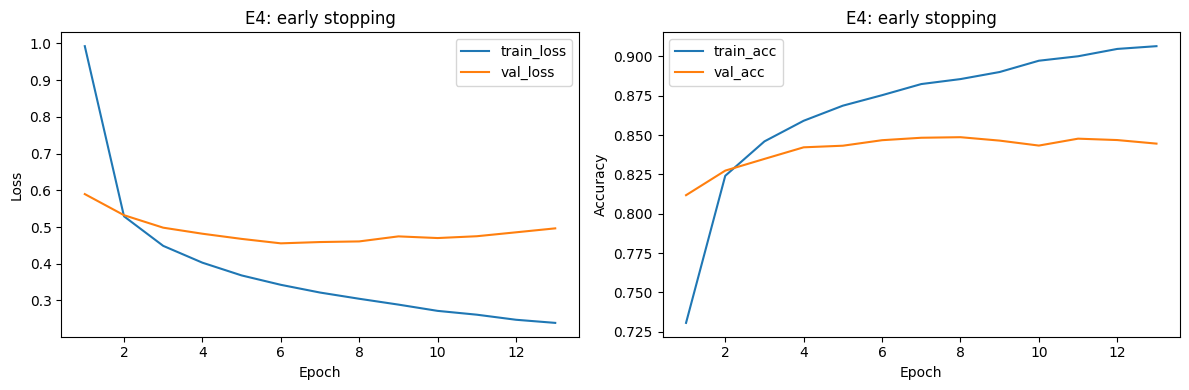

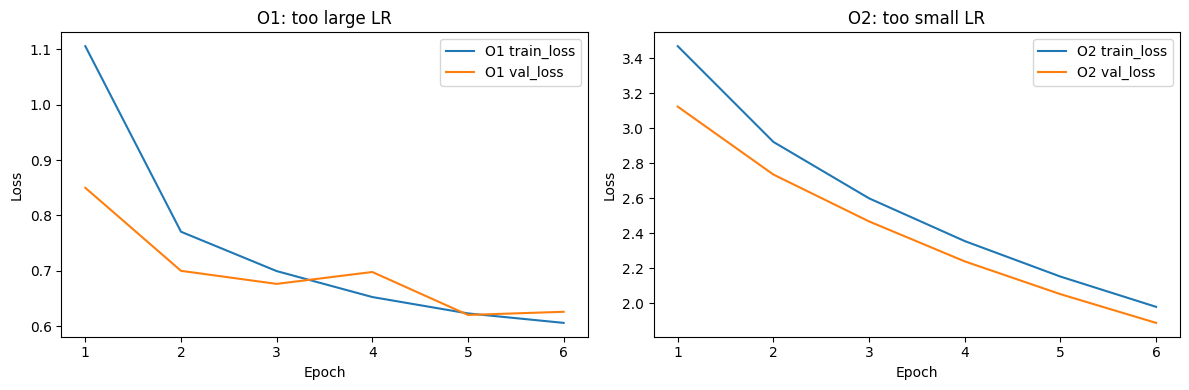

In [9]:
plot_history(
    e4["result"]["history"],
    title="E4: early stopping",
    save_path=FIGURES_DIR / "curves_best.png",
)

history_o1 = o1["result"]["history"]
history_o2 = o2["result"]["history"]

epochs_o1 = range(1, len(history_o1["train_loss"]) + 1)
epochs_o2 = range(1, len(history_o2["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_o1, history_o1["train_loss"], label="O1 train_loss")
plt.plot(epochs_o1, history_o1["val_loss"], label="O1 val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("O1: too large LR")

plt.subplot(1, 2, 2)
plt.plot(epochs_o2, history_o2["train_loss"], label="O2 train_loss")
plt.plot(epochs_o2, history_o2["val_loss"], label="O2 val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("O2: too small LR")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "curves_lr_extremes.png", bbox_inches="tight")
plt.show()

## 8) Проверка готовых артефактов

In [10]:
expected = [
    ARTIFACTS_DIR / "runs.csv",
    ARTIFACTS_DIR / "best_model.pt",
    ARTIFACTS_DIR / "best_config.json",
    FIGURES_DIR / "curves_best.png",
    FIGURES_DIR / "curves_lr_extremes.png",
]

for p in expected:
    print(f"{p}: {'OK' if p.exists() else 'MISSING'}")

artifacts\runs.csv: OK
artifacts\best_model.pt: OK
artifacts\best_config.json: OK
artifacts\figures\curves_best.png: OK
artifacts\figures\curves_lr_extremes.png: OK
